# Librerías

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud
from scipy import stats
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

# Setup

In [2]:
datos = pd.read_csv('train.csv')
df = pd.DataFrame(datos)
nltk.download("stopwords", quiet=True)
nltk.download("vader_lexicon", quiet=True)
stop_words = set(stopwords.words("english"))
df.shape

(7613, 5)

# Análisis exploratorio

In [3]:
df.head(10)

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1
5,8,NaN,NaN,#RockyFire Update => California Hwy. 20 closed...,1
6,10,NaN,NaN,#flood #disaster Heavy rain causes flash flood...,1
7,13,NaN,NaN,I'm on top of the hill and I can see a fire in...,1
8,14,NaN,NaN,There's an emergency evacuation happening now ...,1
9,15,NaN,NaN,I'm afraid that the tornado is coming to our a...,1


In [4]:
def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = texto.replace("#", " ")
    texto = re.sub(r"&\w+;", " ", texto)
    texto = re.sub(r"[^\x00-\x7F]+", " ", texto)
    texto = re.sub(r"[^\w\s]", " ", texto)
    palabras = [p for p in texto.split() if p not in stop_words]
    palabras = [p for p in palabras if not p.isdigit() or p == "911"]
    palabras = [p for p in palabras if len(p) > 1 or p.isdigit()]
    return " ".join(palabras)

df["texto_normalizado"] = df["text"].apply(limpiar_texto)
df[["text", "texto_normalizado"]].head(5)

,text,texto_normalizado
0,Our Deeds are the Reason of this #earthquake M...,deeds reason earthquake may allah forgive us
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada
2,All residents asked to 'shelter in place' are ...,residents asked shelter place notified officer...
3,"13,000 people receive #wildfires evacuation or...",people receive wildfires evacuation orders cal...
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfires pou...


In [5]:
# Frecuencia de palabras
tweets_desastre = df[
    df["target"] == 1
]["texto_normalizado"]

tweets_no_desastre = df[
    df["target"] == 0
]["texto_normalizado"]

palabras_desastre = Counter(
    " ".join(tweets_desastre).split()
)

palabras_no_desastre = Counter(
    " ".join(tweets_no_desastre).split()
)

print("Palabras más comunes en tweets de desastre:")
print(palabras_desastre.most_common(20))
print("------------------------------")
print("Palabras más comunes en tweets no de desastre:")
print(palabras_no_desastre.most_common(20))

Palabras más comunes en tweets de desastre:
[('fire', 182), ('news', 139), ('disaster', 121), ('via', 121), ('california', 115), ('suicide', 112), ('police', 109), ('people', 105), ('killed', 95), ('like', 94), ('hiroshima', 92), ('storm', 89), ('fires', 86), ('crash', 85), ('families', 81), ('train', 79), ('emergency', 77), ('bomb', 76), ('buildings', 76), ('two', 74)]
------------------------------
Palabras más comunes en tweets no de desastre:
[('like', 254), ('new', 171), ('get', 163), ('one', 131), ('body', 116), ('would', 101), ('via', 99), ('video', 96), ('people', 94), ('love', 91), ('day', 86), ('know', 86), ('back', 85), ('time', 84), ('got', 84), ('full', 84), ('see', 82), ('emergency', 81), ('going', 76), ('let', 76)]


In [6]:
# Palabras que aparecen en tweets de desastre y no desastre
comunes = (
    set(palabras_desastre.keys()) &
    set(palabras_no_desastre.keys())
)

frecuencias_comunes = []

for palabra in comunes:
    frecuencias_comunes.append({
        "palabra": palabra,
        "desastre": palabras_desastre[palabra],
        "no_desastre": palabras_no_desastre[palabra]
    })

df_comunes = pd.DataFrame(frecuencias_comunes)

df_comunes["total"] = (
    df_comunes["desastre"] +
    df_comunes["no_desastre"]
)
df_comunes.sort_values(
    "total",
    ascending=False
).head(20)

,palabra,desastre,no_desastre,total
473,like,94,254,348
3334,fire,182,72,254
2420,get,66,163,229
1764,new,56,171,227
759,via,121,99,220
1824,people,105,94,199
1224,news,139,59,198
863,one,66,131,197
308,video,69,96,165
1307,disaster,121,37,158


In [7]:
# Proporción de aparición en tweets de desastre y no desastre
df_comunes["prop_desastre"] = (
    df_comunes["desastre"] /
    df_comunes["total"]
)

df_comunes["prop_no_desastre"] = (
    df_comunes["no_desastre"] /
    df_comunes["total"]
)

In [8]:
# Biogramas
# Para desaste
vectorizador_bi = CountVectorizer(
    ngram_range=(2, 2)
)

X_bi_desastre = vectorizador_bi.fit_transform(
    tweets_desastre
)

frecuencias = X_bi_desastre.sum(axis=0).A1

bigramas_desastre = pd.DataFrame({
    "bigrama": vectorizador_bi.get_feature_names_out(),
    "frecuencia": frecuencias
})

bigramas_desastre.sort_values(
    "frecuencia",
    ascending=False
).head(20)

# Para no desastre
vectorizador_bi_no = CountVectorizer(
    ngram_range=(2, 2)
)

X_bi_no = vectorizador_bi_no.fit_transform(
    tweets_no_desastre
)

frecuencias_no = X_bi_no.sum(axis=0).A1

bigramas_no_desastre = pd.DataFrame({
    "bigrama": vectorizador_bi_no.get_feature_names_out(),
    "frecuencia": frecuencias_no
})

bigramas_no_desastre.sort_values(
    "frecuencia",
    ascending=False
).head(20)

,bigrama,frecuencia
5026,cross body,39
13277,liked video,34
9005,full read,28
2630,body bag,27
2632,body bagging,24
3155,burning buildings,23
2633,body bags,22
18060,quarantine offensive,21
13655,looks like,21
18506,reddit quarantine,21


## Estructura del conjunto de datos

In [9]:
print(df.info())
print(df.isna().sum())
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(4))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 7613 non-null   int64 
 1   keyword            7552 non-null   object
 2   location           5080 non-null   object
 3   text               7613 non-null   object
 4   target             7613 non-null   int64 
 5   texto_normalizado  7613 non-null   object
dtypes: int64(2), object(4)
memory usage: 357.0+ KB
None
id                      0
keyword                61
location             2533
text                    0
target                  0
texto_normalizado       0
dtype: int64
target
0    4342
1    3271
Name: count, dtype: int64
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64


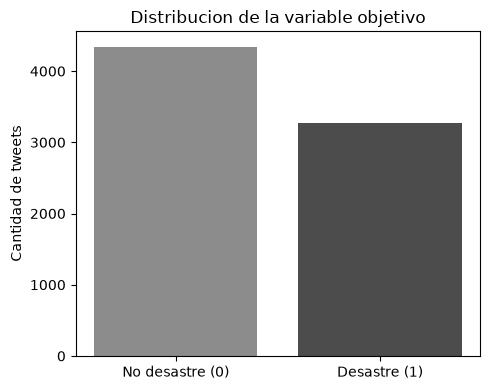

In [10]:
conteo = df["target"].value_counts().sort_index()
plt.figure(figsize=(5, 4))
plt.bar(["No desastre (0)", "Desastre (1)"], conteo.values, color=["#8c8c8c", "#4c4c4c"])
plt.ylabel("Cantidad de tweets")
plt.title("Distribucion de la variable objetivo")
plt.tight_layout()
plt.savefig("img/distribucion_target.png", dpi=120)
plt.show()

In [11]:
print(df["keyword"].nunique(), df["location"].nunique())
top_keywords = df.groupby("keyword")["target"].agg(["count", "mean"])
print(top_keywords.sort_values("mean", ascending=False).head(15))
print(top_keywords.sort_values("mean").head(15))

221 3341
                    count      mean
keyword                            
derailment             39  1.000000
debris                 37  1.000000
wreckage               39  1.000000
outbreak               40  0.975000
typhoon                38  0.973684
oil%20spill            38  0.973684
suicide%20bombing      33  0.969697
suicide%20bomber       31  0.967742
bombing                29  0.931034
rescuers               35  0.914286
suicide%20bomb         35  0.914286
nuclear%20disaster     34  0.911765
evacuated              36  0.888889
razed                  35  0.885714
wildfire               33  0.878788
             count      mean
keyword                     
aftershock      34  0.000000
body%20bags     41  0.024390
ruin            37  0.027027
blazing         34  0.029412
body%20bag      33  0.030303
electrocute     32  0.031250
screaming       36  0.055556
traumatised     35  0.057143
panicking       33  0.060606
blew%20up       33  0.060606
blight          32  0.062500
wr

In [12]:
df["n_palabras"] = df["text"].str.split().str.len()
df["n_caracteres"] = df["text"].str.len()
df["n_palabras_limpias"] = df["texto_normalizado"].str.split().str.len()
print(df.groupby("target")[["n_palabras", "n_caracteres", "n_palabras_limpias"]].mean().round(2))

        n_palabras  n_caracteres  n_palabras_limpias
target                                              
0            14.70         95.83                8.15
1            15.17        108.24                9.23


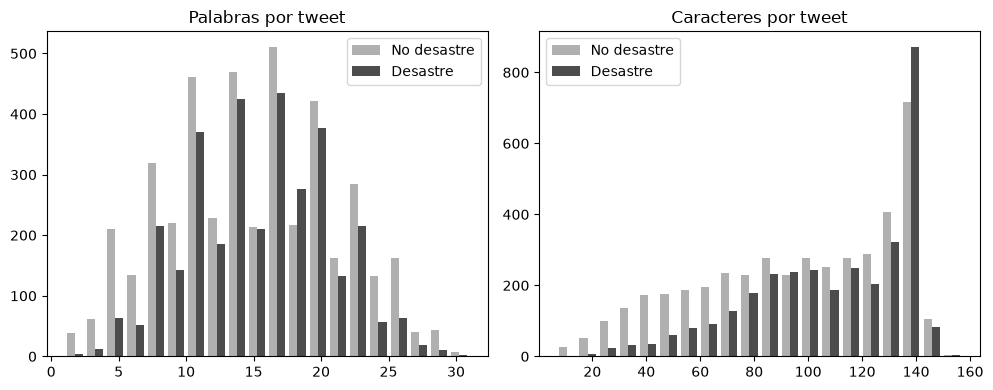

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist([df[df.target == 0]["n_palabras"], df[df.target == 1]["n_palabras"]],
           bins=20, label=["No desastre", "Desastre"], color=["#b0b0b0", "#4c4c4c"])
ax[0].set_title("Palabras por tweet")
ax[0].legend()
ax[1].hist([df[df.target == 0]["n_caracteres"], df[df.target == 1]["n_caracteres"]],
           bins=20, label=["No desastre", "Desastre"], color=["#b0b0b0", "#4c4c4c"])
ax[1].set_title("Caracteres por tweet")
ax[1].legend()
plt.tight_layout()
plt.savefig("img/longitud_tweets.png", dpi=120)
plt.show()

## Nubes de palabras e histogramas de frecuencia

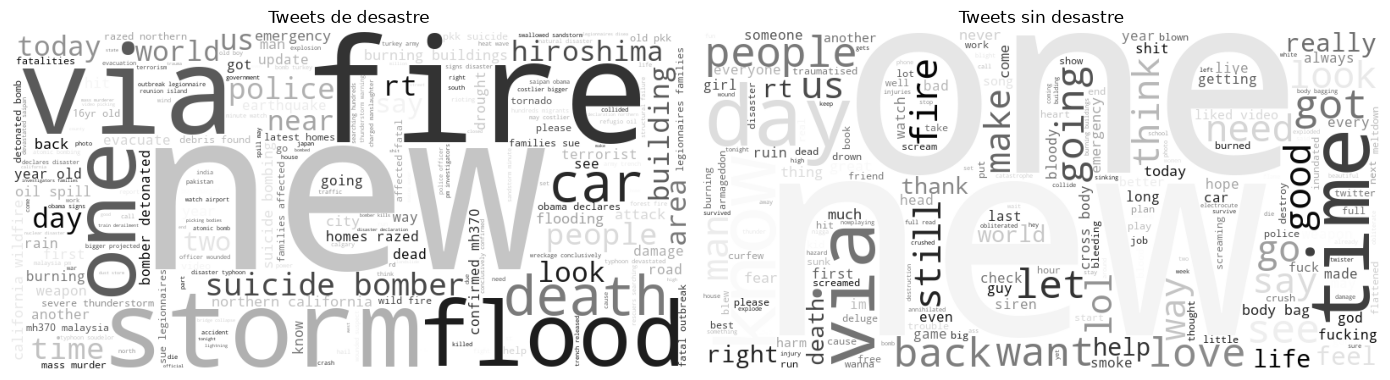

In [14]:
nube_desastre = WordCloud(width=800, height=400, background_color="white",
                          colormap="gray").generate(" ".join(tweets_desastre))
nube_no = WordCloud(width=800, height=400, background_color="white",
                    colormap="gray").generate(" ".join(tweets_no_desastre))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].imshow(nube_desastre)
ax[0].axis("off")
ax[0].set_title("Tweets de desastre")
ax[1].imshow(nube_no)
ax[1].axis("off")
ax[1].set_title("Tweets sin desastre")
plt.tight_layout()
plt.savefig("img/nubes_palabras.png", dpi=120)
plt.show()

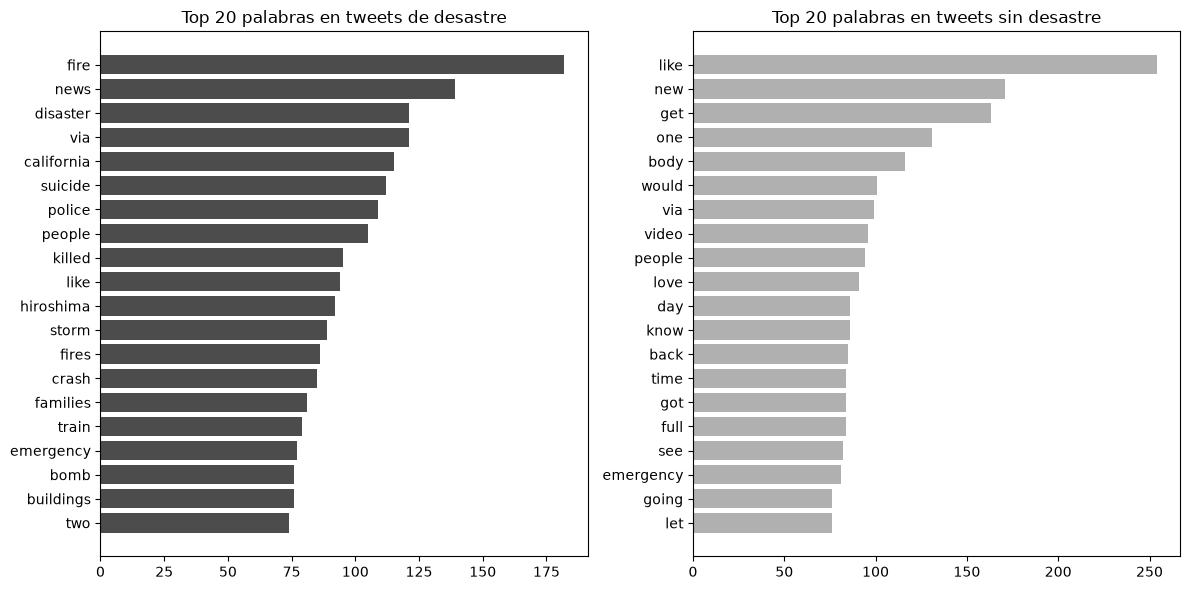

In [15]:
top_d = pd.DataFrame(palabras_desastre.most_common(20), columns=["palabra", "frecuencia"])
top_n = pd.DataFrame(palabras_no_desastre.most_common(20), columns=["palabra", "frecuencia"])

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].barh(top_d["palabra"][::-1], top_d["frecuencia"][::-1], color="#4c4c4c")
ax[0].set_title("Top 20 palabras en tweets de desastre")
ax[1].barh(top_n["palabra"][::-1], top_n["frecuencia"][::-1], color="#b0b0b0")
ax[1].set_title("Top 20 palabras en tweets sin desastre")
plt.tight_layout()
plt.savefig("img/top_palabras.png", dpi=120)
plt.show()

## Palabras mas discriminantes

In [16]:
filtro = df_comunes[df_comunes["total"] >= 30].copy()
mas_desastre = filtro.sort_values("prop_desastre", ascending=False).head(20)
mas_no_desastre = filtro.sort_values("prop_no_desastre", ascending=False).head(20)
print(mas_desastre[["palabra", "desastre", "no_desastre", "prop_desastre"]].to_string(index=False))
print(mas_no_desastre[["palabra", "desastre", "no_desastre", "prop_no_desastre"]].to_string(index=False))

  palabra  desastre  no_desastre  prop_desastre
hiroshima        92            1       0.989247
   bomber        60            1       0.983607
  typhoon        58            1       0.983051
 malaysia        49            1       0.980000
    spill        43            1       0.977273
 outbreak        40            1       0.975610
 wreckage        40            1       0.975610
    saudi        40            1       0.975610
  suspect        35            1       0.972222
    kills        35            1       0.972222
 wildfire        69            2       0.971831
 hundreds        34            1       0.971429
  reunion        32            1       0.969697
 affected        32            1       0.969697
officials        30            1       0.967742
  airport        29            1       0.966667
   atomic        56            2       0.965517
   killed        95            4       0.959596
confirmed        45            2       0.957447
  bombing        67            3       0

In [17]:
ambiguas = filtro[(filtro["prop_desastre"] > 0.45) & (filtro["prop_desastre"] < 0.55)]
print(ambiguas.sort_values("total", ascending=False).head(20)[["palabra", "desastre", "no_desastre", "total"]].to_string(index=False))

  palabra  desastre  no_desastre  total
   people       105           94    199
emergency        77           81    158
  burning        64           57    121
    first        50           59    109
    could        38           45     83
    death        36           39     75
  another        33           39     72
     live        30           32     62
     said        26           31     57
   flames        29           28     57
    since        29           24     53
      hit        29           24     53
     plan        23           26     49
    cause        22           26     48
      set        23           25     48
  weapons        21           23     44
   family        24           20     44
    house        22           22     44
    china        20           23     43
   rescue        22           20     42


## Bigramas y trigramas

In [18]:
bi_d = bigramas_desastre.sort_values("frecuencia", ascending=False).head(15)
bi_n = bigramas_no_desastre.sort_values("frecuencia", ascending=False).head(15)
print(bi_d.to_string(index=False))
print(bi_n.to_string(index=False))

            bigrama  frecuencia
     suicide bomber          59
northern california          41
          oil spill          38
  burning buildings          36
    suicide bombing          35
california wildfire          34
   bomber detonated          30
        homes razed          29
    confirmed mh370          29
        pkk suicide          28
     razed northern          28
     detonated bomb          28
       latest homes          28
           16yr old          28
           year old          28
             bigrama  frecuencia
          cross body          39
         liked video          34
           full read          28
            body bag          27
        body bagging          24
   burning buildings          23
           body bags          22
quarantine offensive          21
          looks like          21
   reddit quarantine          21
           feel like          20
   offensive content          20
      content policy          20
           loud bang      

In [19]:
def ngramas(corpus, n, top=15):
    vec = CountVectorizer(ngram_range=(n, n))
    X = vec.fit_transform(corpus)
    tabla = pd.DataFrame({"ngrama": vec.get_feature_names_out(),
                          "frecuencia": X.sum(axis=0).A1})
    return tabla.sort_values("frecuencia", ascending=False).head(top).reset_index(drop=True)

tri_desastre = ngramas(tweets_desastre, 3)
tri_no_desastre = ngramas(tweets_no_desastre, 3)
print(tri_desastre.to_string(index=False))
print(tri_no_desastre.to_string(index=False))

                      ngrama  frecuencia
    suicide bomber detonated          30
northern california wildfire          29
       bomber detonated bomb          28
        homes razed northern          28
          pkk suicide bomber          28
          latest homes razed          28
             old pkk suicide          27
   razed northern california          27
                16yr old pkk          27
     affected fatal outbreak          26
   families sue legionnaires          26
     families affected fatal          26
   typhoon devastated saipan          25
 disaster typhoon devastated          25
   sue legionnaires families          25
                       ngrama  frecuencia
  reddit quarantine offensive          21
 quarantine offensive content          20
               cross body bag          19
                pick fan army          17
           stock market crash          16
           china stock market          16
           new content policy          16
        

In [20]:
total_bi_d = bigramas_desastre["frecuencia"].sum()
prob_bi_d = bigramas_desastre.sort_values("frecuencia", ascending=False).head(10).copy()
prob_bi_d["probabilidad"] = (prob_bi_d["frecuencia"] / total_bi_d).round(5)
print(prob_bi_d.to_string(index=False))

            bigrama  frecuencia  probabilidad
     suicide bomber          59       0.00219
northern california          41       0.00152
          oil spill          38       0.00141
  burning buildings          36       0.00134
    suicide bombing          35       0.00130
california wildfire          34       0.00126
   bomber detonated          30       0.00111
        homes razed          29       0.00108
    confirmed mh370          29       0.00108
        pkk suicide          28       0.00104


## Modelos de clasificacion

In [21]:
X = df["texto_normalizado"]
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_vec = vectorizador.fit_transform(X_train)
X_test_vec = vectorizador.transform(X_test)
print(X_train_vec.shape, X_test_vec.shape)

(5709, 8729) (1904, 8729)


In [22]:
modelos = {
    "Naive Bayes": MultinomialNB(alpha=0.5),
    "Regresion Logistica": LogisticRegression(C=5, max_iter=1000),
    "SVM lineal": LinearSVC(C=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
}

resultados = []
predicciones = {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train_vec, y_train)
    pred = modelo.predict(X_test_vec)
    predicciones[nombre] = pred
    resultados.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

tabla_resultados = pd.DataFrame(resultados).round(4)
tabla_resultados

,modelo,accuracy,precision,recall,f1
0,Naive Bayes,0.8178,0.8563,0.6919,0.7654
1,Regresion Logistica,0.8125,0.8029,0.7469,0.7739
2,SVM lineal,0.8125,0.8045,0.7445,0.7733
3,Random Forest,0.7946,0.8063,0.6870,0.7419


In [23]:
for nombre, modelo in modelos.items():
    tuberia = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
        ("modelo", modelo.__class__(**modelo.get_params()))
    ])
    puntajes = cross_val_score(tuberia, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=42), scoring="f1")
    print(nombre, puntajes.mean().round(4), puntajes.std().round(4))

Naive Bayes 0.7409 0.0169


Regresion Logistica 0.7505 0.0092


SVM lineal 0.7501 0.0086


Random Forest 0.7396 0.0103


In [24]:
mejor_nombre = tabla_resultados.sort_values("f1", ascending=False).iloc[0]["modelo"]
mejor_modelo = modelos[mejor_nombre]
print(mejor_nombre)
print(classification_report(y_test, predicciones[mejor_nombre],
                           target_names=["No desastre", "Desastre"]))

Regresion Logistica
              precision    recall  f1-score   support

 No desastre       0.82      0.86      0.84      1086
    Desastre       0.80      0.75      0.77       818

    accuracy                           0.81      1904
   macro avg       0.81      0.80      0.81      1904
weighted avg       0.81      0.81      0.81      1904



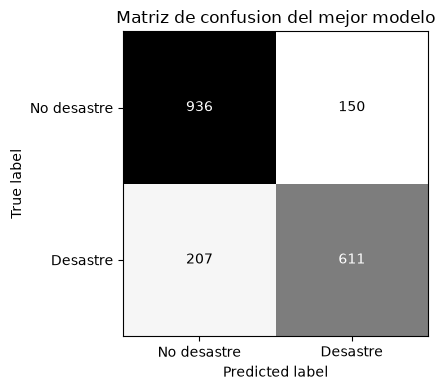

In [25]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, predicciones[mejor_nombre]),
                       display_labels=["No desastre", "Desastre"]).plot(ax=ax, cmap="Greys", colorbar=False)
plt.title("Matriz de confusion del mejor modelo")
plt.tight_layout()
plt.savefig("img/matriz_confusion.png", dpi=120)
plt.show()

In [26]:
coeficientes = pd.DataFrame({
    "termino": vectorizador.get_feature_names_out(),
    "peso": LogisticRegression(C=5, max_iter=1000).fit(X_train_vec, y_train).coef_[0]
})
print(coeficientes.sort_values("peso", ascending=False).head(15).to_string(index=False))
print(coeficientes.sort_values("peso").head(15).to_string(index=False))

   termino     peso
 hiroshima 6.022535
     fires 4.874583
     storm 4.584317
california 4.259135
earthquake 4.239793
  wildfire 4.199707
    floods 4.083211
   typhoon 3.922566
    killed 3.867828
      near 3.748290
     japan 3.697907
    police 3.659444
     train 3.539663
   bombing 3.373728
  evacuate 3.367848
  termino      peso
     show -3.316134
 upheaval -2.960289
      new -2.858600
     fuck -2.813347
     harm -2.761148
     cake -2.689424
    never -2.658080
     love -2.627598
     book -2.616211
stretcher -2.614852
  blazing -2.580169
     lmao -2.574118
     ruin -2.501719
    thank -2.500466
    phone -2.486952


## Funcion de clasificacion de nuevos tweets

In [27]:
def clasificar_tweet(tweet, modelo=None, vec=None):
    modelo = modelo if modelo is not None else mejor_modelo
    vec = vec if vec is not None else vectorizador
    limpio = limpiar_texto(tweet)
    X_nuevo = vec.transform([limpio])
    etiqueta = int(modelo.predict(X_nuevo)[0])
    if hasattr(modelo, "predict_proba"):
        confianza = float(modelo.predict_proba(X_nuevo)[0][etiqueta])
    else:
        confianza = float(abs(modelo.decision_function(X_nuevo)[0]))
    return {
        "tweet": tweet,
        "texto_limpio": limpio,
        "clasificacion": "Desastre real" if etiqueta == 1 else "No desastre",
        "target": etiqueta,
        "confianza": round(confianza, 4)
    }

ejemplos = [
    "Forest fire near La Ronge Sask. Canada",
    "I just finished my homework and I am so happy",
    "BREAKING: 7.1 earthquake hits the coast, buildings collapsed and people are trapped",
    "This new song is a total disaster lol"
]
for e in ejemplos:
    print(clasificar_tweet(e))

{'tweet': 'Forest fire near La Ronge Sask. Canada', 'texto_limpio': 'forest fire near la ronge sask canada', 'clasificacion': 'Desastre real', 'target': 1, 'confianza': 0.9878}
{'tweet': 'I just finished my homework and I am so happy', 'texto_limpio': 'finished homework happy', 'clasificacion': 'No desastre', 'target': 0, 'confianza': 0.9331}
{'tweet': 'BREAKING: 7.1 earthquake hits the coast, buildings collapsed and people are trapped', 'texto_limpio': 'breaking earthquake hits coast buildings collapsed people trapped', 'clasificacion': 'Desastre real', 'target': 1, 'confianza': 0.9778}
{'tweet': 'This new song is a total disaster lol', 'texto_limpio': 'new song total disaster lol', 'clasificacion': 'No desastre', 'target': 0, 'confianza': 0.9208}


## Analisis de sentimiento

In [28]:
def limpiar_para_sentimiento(texto):
    texto = str(texto)
    texto = re.sub(r"http\S+|www\S+", " ", texto)
    texto = re.sub(r"@\w+", " ", texto)
    texto = re.sub(r"&\w+;", " ", texto)
    texto = texto.replace("#", " ")
    return re.sub(r"\s+", " ", texto).strip()

analizador = SentimentIntensityAnalyzer()
df["texto_sentimiento"] = df["text"].apply(limpiar_para_sentimiento)
puntajes = df["texto_sentimiento"].apply(analizador.polarity_scores)
df["pos"] = puntajes.apply(lambda d: d["pos"])
df["neg"] = puntajes.apply(lambda d: d["neg"])
df["neu"] = puntajes.apply(lambda d: d["neu"])
df["compound"] = puntajes.apply(lambda d: d["compound"])

def etiqueta_sentimiento(c):
    if c >= 0.05:
        return "positivo"
    if c <= -0.05:
        return "negativo"
    return "neutro"

df["sentimiento"] = df["compound"].apply(etiqueta_sentimiento)
print(df["sentimiento"].value_counts())
print(pd.crosstab(df["target"], df["sentimiento"], normalize="index").round(4))

sentimiento
negativo    3738
neutro      1946
positivo    1929
Name: count, dtype: int64
sentimiento  negativo  neutro  positivo
target                                 
0              0.4275  0.2517    0.3208
1              0.5754  0.2608    0.1639


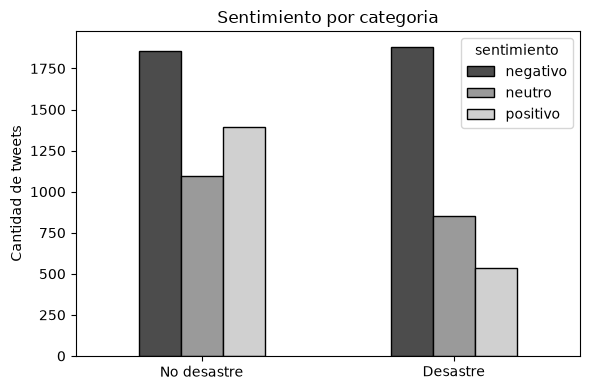

In [29]:
tabla_sent = pd.crosstab(df["target"], df["sentimiento"])
tabla_sent = tabla_sent[["negativo", "neutro", "positivo"]]
tabla_sent.index = ["No desastre", "Desastre"]
tabla_sent.plot(kind="bar", figsize=(6, 4), color=["#4c4c4c", "#9a9a9a", "#d0d0d0"], edgecolor="black")
plt.ylabel("Cantidad de tweets")
plt.title("Sentimiento por categoria")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("img/sentimiento_categoria.png", dpi=120)
plt.show()

In [30]:
palabras_pos = []
palabras_neg = []
for palabra, valor in analizador.lexicon.items():
    if valor >= 1.5:
        palabras_pos.append(palabra)
    elif valor <= -1.5:
        palabras_neg.append(palabra)

vocabulario = set(" ".join(df["texto_normalizado"]).split())
pos_corpus = Counter({p: c for p, c in Counter(" ".join(df["texto_normalizado"]).split()).items() if p in palabras_pos})
neg_corpus = Counter({p: c for p, c in Counter(" ".join(df["texto_normalizado"]).split()).items() if p in palabras_neg})
print(len(palabras_pos), len(palabras_neg))
print(pos_corpus.most_common(15))
print(neg_corpus.most_common(15))

1912 2287
[('like', 348), ('love', 102), ('good', 89), ('best', 75), ('help', 74), ('lol', 71), ('great', 62), ('hope', 53), ('natural', 45), ('free', 44), ('liked', 44), ('rescue', 42), ('save', 41), ('rescued', 40), ('survived', 39)]
[('disaster', 158), ('emergency', 158), ('crash', 119), ('suicide', 119), ('bomb', 105), ('attack', 101), ('killed', 99), ('dead', 98), ('war', 92), ('accident', 89), ('collapse', 76), ('death', 75), ('fatal', 67), ('wreck', 60), ('fear', 57)]


## Tweets mas positivos y mas negativos

In [31]:
mas_negativos = df.sort_values("compound").head(10)[["text", "target", "compound"]]
mas_positivos = df.sort_values("compound", ascending=False).head(10)[["text", "target", "compound"]]
print(mas_negativos.to_string(index=False))
print(mas_positivos["target"].value_counts())
print(mas_negativos["target"].value_counts())

                                                                                                                                           text  target  compound
                                                                wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?       0   -0.9883
  @Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bomber targets Saudi mosque at least 13 dead\r\nThis is ridiculous       1   -0.9686
   Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed at least 15 people in an attack on... http://t.co/FY0r9o7Xsl       1   -0.9623
    ? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; Blamed: Boko Haram [L.A. Times/AP] | http://t.co/O2cdKpSDfp       1   -0.9595
17 killed in SÛªArabia mosque suicide bombing\r\n\r\nA suicide bomber attacked a mosque in Aseer south-western Saudi... http://t.co/pMTQhiVsXX       1   -0.9552
             at the lake \r\

In [32]:
print(mas_positivos.to_string(index=False))

                                                                                                                                          text  target  compound
Check out 'Want Twister Tickets AND A VIP EXPERIENCE To See SHANIA? CLICK HERE:' at  http://t.co/3GEROQ49o1\r\nI would Love Love Love!! To win       0    0.9730
                   @thoutaylorbrown I feel like accidents are just drawn to you but I'm happy you've survived all of them. Hope you're okay!!!       0    0.9564
           TodayÛªs storm will pass; let tomorrowÛªs light greet you with a kiss. Bask in this loving warmth; let your soul return to bliss.       1    0.9471
                               @batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.       0    0.9423
                               @batfanuk we enjoyed the show today. Great fun. The emergency non evacuation was interesting. Have a great run.       0    0.9423
                Free Ebay Sniping 

In [33]:
print(df.groupby("target")["compound"].agg(["mean", "median", "std"]).round(4))
g0 = df[df.target == 0]["compound"]
g1 = df[df.target == 1]["compound"]
t, p = stats.ttest_ind(g0, g1, equal_var=False)
print(t.round(4), p)
u, pu = stats.mannwhitneyu(g0, g1)
print(u, pu)

          mean  median     std
target                        
0      -0.0569  0.0000  0.4612
1      -0.2674 -0.3182  0.4346
20.3792 8.135839533730396e-90
8919712.5 5.245863028875586e-83


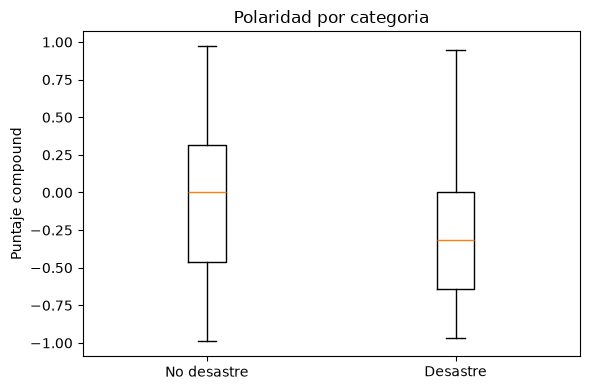

In [34]:
plt.figure(figsize=(6, 4))
plt.boxplot([g0, g1], tick_labels=["No desastre", "Desastre"])
plt.ylabel("Puntaje compound")
plt.title("Polaridad por categoria")
plt.tight_layout()
plt.savefig("img/polaridad_categoria.png", dpi=120)
plt.show()

## Variable de negatividad y reentrenamiento

In [35]:
df["negatividad"] = (1 - df["compound"]) / 2
print(df.groupby("target")["negatividad"].mean().round(4))
df[["text", "target", "compound", "negatividad"]].head(5)

target
0    0.5284
1    0.6337
Name: negatividad, dtype: float64


,text,target,compound,negatividad
0,Our Deeds are the Reason of this #earthquake M...,1,0.2732,0.3634
1,Forest fire near La Ronge Sask. Canada,1,-0.3400,0.6700
2,All residents asked to 'shelter in place' are ...,1,-0.2960,0.6480
3,"13,000 people receive #wildfires evacuation or...",1,0.0000,0.5000
4,Just got sent this photo from Ruby #Alaska as ...,1,0.0000,0.5000


In [36]:
columnas_extra = ["negatividad", "pos", "neg", "neu"]
extra_train = df.loc[X_train.index, columnas_extra].values
extra_test = df.loc[X_test.index, columnas_extra].values
X_train_ext = hstack([X_train_vec, csr_matrix(extra_train)]).tocsr()
X_test_ext = hstack([X_test_vec, csr_matrix(extra_test)]).tocsr()

resultados_ext = []
for nombre, modelo in modelos.items():
    m = modelo.__class__(**modelo.get_params())
    m.fit(X_train_ext, y_train)
    pred = m.predict(X_test_ext)
    resultados_ext.append({
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred)
    })

tabla_ext = pd.DataFrame(resultados_ext).round(4)
tabla_ext

,modelo,accuracy,precision,recall,f1
0,Naive Bayes,0.8157,0.8631,0.6785,0.7598
1,Regresion Logistica,0.8114,0.8000,0.7482,0.7732
2,SVM lineal,0.8088,0.7963,0.7457,0.7702
3,Random Forest,0.7988,0.8548,0.6406,0.7324


In [37]:
comparacion = tabla_resultados.merge(tabla_ext, on="modelo", suffixes=("_base", "_con_negatividad"))
comparacion["dif_f1"] = (comparacion["f1_con_negatividad"] - comparacion["f1_base"]).round(4)
comparacion["dif_accuracy"] = (comparacion["accuracy_con_negatividad"] - comparacion["accuracy_base"]).round(4)
comparacion[["modelo", "f1_base", "f1_con_negatividad", "dif_f1", "accuracy_base", "accuracy_con_negatividad", "dif_accuracy"]]

,modelo,f1_base,f1_con_negatividad,dif_f1,accuracy_base,accuracy_con_negatividad,dif_accuracy
0,Naive Bayes,0.7654,0.7598,-0.0056,0.8178,0.8157,-0.0021
1,Regresion Logistica,0.7739,0.7732,-0.0007,0.8125,0.8114,-0.0011
2,SVM lineal,0.7733,0.7702,-0.0031,0.8125,0.8088,-0.0037
3,Random Forest,0.7419,0.7324,-0.0095,0.7946,0.7988,0.0042


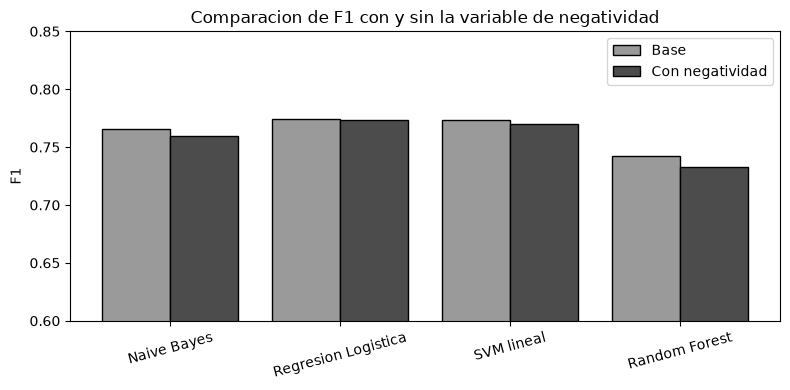

In [38]:
etiquetas = comparacion["modelo"]
pos = np.arange(len(etiquetas))
plt.figure(figsize=(8, 4))
plt.bar(pos - 0.2, comparacion["f1_base"], width=0.4, label="Base", color="#9a9a9a", edgecolor="black")
plt.bar(pos + 0.2, comparacion["f1_con_negatividad"], width=0.4, label="Con negatividad", color="#4c4c4c", edgecolor="black")
plt.xticks(pos, etiquetas, rotation=15)
plt.ylabel("F1")
plt.ylim(0.6, 0.85)
plt.legend()
plt.title("Comparacion de F1 con y sin la variable de negatividad")
plt.tight_layout()
plt.savefig("img/comparacion_f1.png", dpi=120)
plt.show()